In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [70]:
# Reading AI Datacenter locations, filtering out to get active datacenters
datacenters = pd.read_csv('ai_data_centers_consumption_and_locations.csv')

datacenters = datacenters[(datacenters['Country']=='United States') & (datacenters['Current power (MW)'] > 0)]
datacenters['State'] = datacenters['County'].str.split(', ').str[1]
datacenters['County'] = datacenters['County'].str.split(',').str[0]
datacenters.drop(columns = ['Current H100 equivalents',
                            'Current total capital cost (2025 USD billions)',
                            'Owner', 'Users', 'Selected Sources', 'Calculations sheet',
                            'Project', 'Current chip types', 'All chip types', 'Investors',
                            'Construction companies', 'Energy companies', 'Country','Address'], inplace = True)

datacenters_by_county = datacenters.groupby(['County','State']).agg(
    num_datacenters = ('Current power (MW)', 'count'),
    total_power_consumption_mw = ('Current power (MW)', 'sum')
    )
datacenters_by_county = datacenters_by_county.reset_index()
datacenters_by_county['County'] = datacenters_by_county['County'].str.replace(' County', '').str.strip()

# per relavent county, find utility number id
county_to_utility = pd.read_excel('eia861/f8612024/Service_Territory_2024.xlsx', sheet_name='Counties_States')[['State', 'County', 'Utility Number']].drop_duplicates()
county_to_utility['State'] = county_to_utility['State'].str.strip()
county_to_utility['County'] = county_to_utility['County'].str.strip()
df_master = datacenters_by_county.merge(county_to_utility, on=['State', 'County'], how='left')

# loop through past 7 years and obtain residential rates per county using EIA861
year_range = range(2018, 2025)
price_columns = []
for year in year_range:
    file_path = f'eia861/f861{year}/Sales_Ult_Cust_{year}.xlsx'
    df_sales = pd.read_excel(file_path, sheet_name='States', header=2)

    # calculate the residential price, keep only prices associated with physical infrastructure
    df_sales['Megawatthours'] = pd.to_numeric(df_sales['Megawatthours'], errors='coerce')
    df_sales['Thousand Dollars'] = pd.to_numeric(df_sales['Thousand Dollars'], errors='coerce')
    df_sales = df_sales[df_sales['Part'].isin(['A', 'C']) & (df_sales['Megawatthours'] > 0)].copy()
    price_col = f'Price_{year}_MWh'
    price_columns.append(price_col)
    df_sales[price_col] = (df_sales['Thousand Dollars'] * 1000) / df_sales['Megawatthours']
    
    # Average the price per utility provider and put back into df_master
    utility_prices = df_sales.groupby(['Utility Number', 'State'])[price_col].mean().reset_index()
    df_master = df_master.merge(utility_prices, on=['Utility Number', 'State'], how='left')

# recreate final dataframe, averaging utilities providing the same county in the same year
final_treatment_group = (df_master
                         .groupby(['County', 'State', 'num_datacenters', 'total_power_consumption_mw'])[price_columns]
                         .mean()
                         .reset_index()
                         .sort_values(by=['num_datacenters', 'total_power_consumption_mw'], ascending=[False, False]))

# final_treatment_group

In [71]:
# load full state/county service territory mapping for true state-demeaning baseline
full_counties = pd.read_excel('eia861/f8612024/Service_Territory_2024.xlsx', sheet_name='Counties_States')[['State', 'County', 'Utility Number']].drop_duplicates()
full_counties['State'] = full_counties['State'].str.strip()
full_counties['County'] = full_counties['County'].str.strip()

# helper to calculate residential prices per utility for any year
def get_utility_prices(year):
    df = pd.read_excel(f'eia861/f861{year}/Sales_Ult_Cust_{year}.xlsx', sheet_name='States', header=2)
    df['Megawatthours'] = pd.to_numeric(df['Megawatthours'], errors='coerce')
    df['Thousand Dollars'] = pd.to_numeric(df['Thousand Dollars'], errors='coerce')
    df = df[df['Part'].isin(['A', 'C']) & (df['Megawatthours'] > 0)].copy()
    col = f'Price_{year}_MWh'
    df[col] = (df['Thousand Dollars'] * 1000) / df['Megawatthours']
    return df.groupby(['Utility Number', 'State'])[col].mean().reset_index()

# compute true statewide growth mean using all counties across 2018 and 2024
fp = full_counties.merge(get_utility_prices(2018), on=['Utility Number', 'State'], how='left')
fp = fp.merge(get_utility_prices(2024), on=['Utility Number', 'State'], how='left')
fp['Growth'] = ((fp['Price_2024_MWh'] - fp['Price_2018_MWh']) / fp['Price_2018_MWh']) * 100
state_means = fp.groupby('State')['Growth'].mean().reset_index().rename(columns={'Growth': 'True_State_Mean_Growth'})

# merge true state mean back into final treatment group
final_treatment_group = final_treatment_group.merge(state_means, on='State', how='left')

# build control_final using matched controls
control_final = control_demographics.merge(county_to_utility, on=['State', 'County'], how='inner').drop_duplicates(subset=['County', 'State'])
control_final['num_datacenters'] = 0
control_final['total_power_consumption_mw'] = 0
control_final['Treatment_Tier'] = 'Control (0 MW)'

# loop to pull control prices across 2018-2024
for year in range(2018, 2025):
    control_final = control_final.merge(get_utility_prices(year), on=['Utility Number', 'State'], how='left')

# concatenate treatment and control into one universal dataframe
universal_panel = pd.concat([final_treatment_group, control_final], ignore_index=True)

# calculate growth metrics and universal state demeaning
universal_panel['Price_Growth_Pct'] = ((universal_panel['Price_2024_MWh'] - universal_panel['Price_2018_MWh']) / universal_panel['Price_2018_MWh']) * 100
universal_panel['True_State_Demeaned_Growth'] = universal_panel['Price_Growth_Pct'] - universal_panel.groupby('State')['Price_Growth_Pct'].transform('mean')

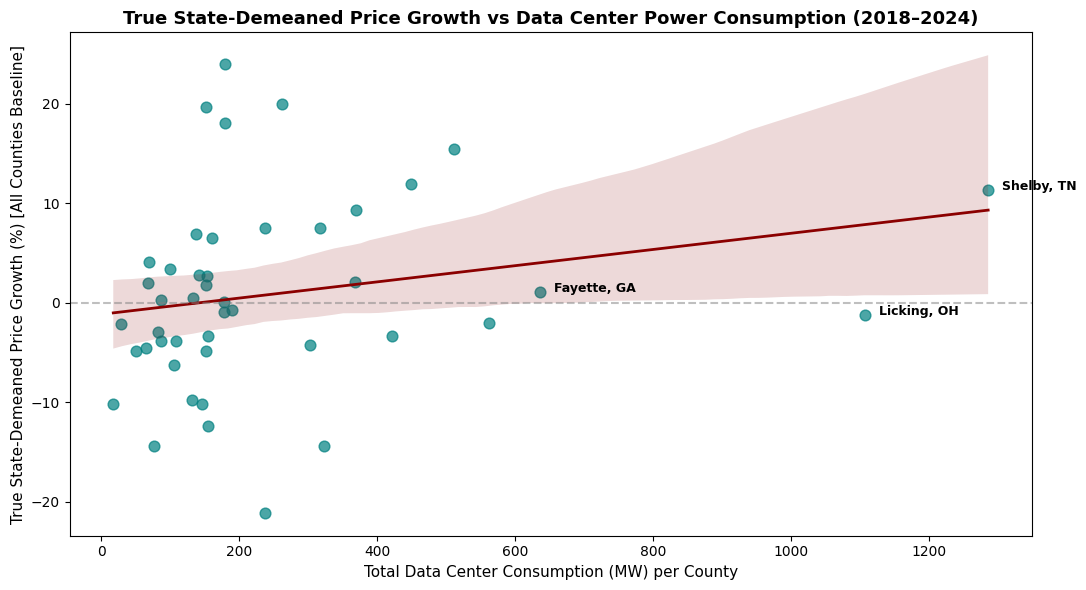

In [72]:
#TREATING LINEARLY

final_treatment_group['Price_Growth_Pct'] = (
    (final_treatment_group['Price_2024_MWh'] - final_treatment_group['Price_2018_MWh']) 
    / final_treatment_group['Price_2018_MWh']
) * 100

# 2. Demean the price growth relative to true statewide averages (all counties)
final_treatment_group['Growth_Demeaned'] = (
    final_treatment_group['Price_Growth_Pct'] 
    - final_treatment_group['True_State_Mean_Growth']
)

# Filter missing values
plot_df = final_treatment_group.dropna(subset=['Growth_Demeaned', 'total_power_consumption_mw'])

# Generate linear regression scatter plot
plt.figure(figsize=(11, 6))
sns.regplot(
    data=plot_df, 
    x='total_power_consumption_mw', 
    y='Growth_Demeaned', 
    scatter_kws={'alpha': 0.7, 'color': 'teal', 's': 60}, 
    line_kws={'color': 'darkred', 'linewidth': 2}
)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('True State-Demeaned Price Growth vs Data Center Power Consumption (2018–2024)', fontsize=13, fontweight='bold')
plt.xlabel('Total Data Center Consumption (MW) per County', fontsize=11)
plt.ylabel('True State-Demeaned Price Growth (%) [All Counties Baseline]', fontsize=11)

# Label the top 3 highest-consumption counties directly on the plot
top_counties = plot_df.nlargest(3, 'total_power_consumption_mw')
for _, row in top_counties.iterrows():
    plt.text(
        row['total_power_consumption_mw'] + 20, 
        row['Growth_Demeaned'], 
        f"{row['County']}, {row['State']}", 
        fontsize=9, weight='bold'
    )

plt.tight_layout()
plt.show()

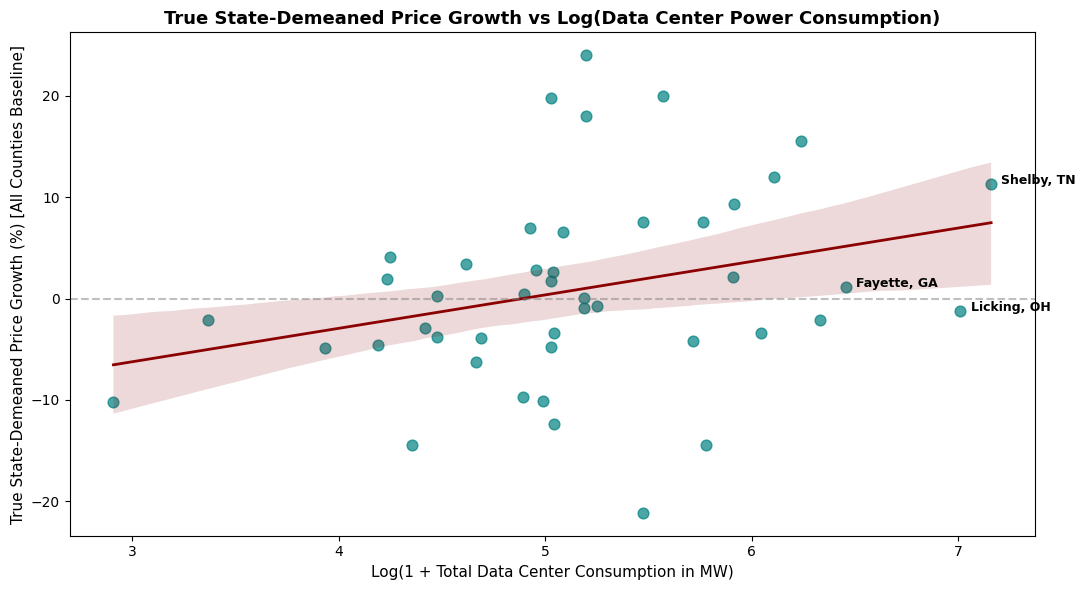

In [73]:
#TREATING X LOGARITHMICALLY

final_treatment_group['Price_Growth_Pct'] = (
    (final_treatment_group['Price_2024_MWh'] - final_treatment_group['Price_2018_MWh']) 
    / final_treatment_group['Price_2018_MWh']
) * 100

# Demean using true statewide average from all counties
final_treatment_group['Growth_Demeaned'] = (
    final_treatment_group['Price_Growth_Pct'] 
    - final_treatment_group['True_State_Mean_Growth']
)

# applying log transform to x axis due to right skewing
final_treatment_group['Log_MW'] = np.log1p(final_treatment_group['total_power_consumption_mw'])

plot_df = final_treatment_group.dropna(subset=['Growth_Demeaned', 'Log_MW'])

plt.figure(figsize=(11, 6))
sns.regplot(
    data=plot_df, 
    x='Log_MW', 
    y='Growth_Demeaned', 
    scatter_kws={'alpha': 0.7, 'color': 'teal', 's': 60}, 
    line_kws={'color': 'darkred', 'linewidth': 2}
)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('True State-Demeaned Price Growth vs Log(Data Center Power Consumption)', fontsize=13, fontweight='bold')
plt.xlabel('Log(1 + Total Data Center Consumption in MW)', fontsize=11)
plt.ylabel('True State-Demeaned Price Growth (%) [All Counties Baseline]', fontsize=11)

top_counties = plot_df.nlargest(3, 'Log_MW')
for _, row in top_counties.iterrows():
    plt.text(
        row['Log_MW'] + 0.05, 
        row['Growth_Demeaned'], 
        f"{row['County']}, {row['State']}", 
        fontsize=9, weight='bold'
    )

plt.tight_layout()
plt.show()

In [33]:
# 1. Load Census / USDA ERS Datasets
pop_df = pd.read_csv('census_data/PopulationEstimates.csv', encoding='latin1')
inc_df = pd.read_csv('census_data/Unemployment2023.csv', encoding='latin1')

# 2. Extract Population (2021) and Median Household Income (2022)
pop_sub = pop_df[pop_df['Attribute'] == 'POP_ESTIMATE_2021'][['FIPStxt', 'State', 'Area_Name', 'Value']].copy()
pop_sub.rename(columns={'FIPStxt': 'FIPS', 'Value': 'Population_2021'}, inplace=True)
pop_sub['Population_2021'] = pd.to_numeric(pop_sub['Population_2021'].astype(str).str.replace(',', ''), errors='coerce')

inc_sub = inc_df[inc_df['Attribute'] == 'Median_Household_Income_2022'][['FIPS_Code', 'State', 'Area_Name', 'Value']].copy()
inc_sub.rename(columns={'FIPS_Code': 'FIPS', 'Value': 'Median_Income_2022'}, inplace=True)
inc_sub['Median_Income_2022'] = pd.to_numeric(inc_sub['Median_Income_2022'].astype(str).str.replace(',', ''), errors='coerce')

# Merge Census stats together
census_merged = pop_sub.merge(inc_sub[['FIPS', 'Median_Income_2022']], on='FIPS', how='inner')
census_merged['County'] = census_merged['Area_Name'].str.replace(' County', '').str.replace(r',\s*[A-Z]{2}', '', regex=True).str.strip()
census_merged['State'] = census_merged['State'].str.strip()

# 3. Isolate Control Counties (Exclude counties present in final_treatment_group)
treated_counties = final_treatment_group[['State', 'County']].drop_duplicates()
treated_counties['Is_Treatment'] = True

control_pool = census_merged.merge(treated_counties, on=['State', 'County'], how='left')
control_pool = control_pool[control_pool['Is_Treatment'].isna()].copy()

# This is your clean dataframe of control counties with matching statistics!
control_demographics = control_pool[['County', 'State', 'Population_2021', 'Median_Income_2022']].dropna()
control_demographics

,County,State,Population_2021,Median_Income_2022
0,United States,US,332048977.0,74755.0
1,Alabama,AL,5050380.0,59703.0
2,Autauga,AL,59203.0,70148.0
3,Baldwin,AL,239439.0,71704.0
4,Barbour,AL,24533.0,41151.0
...,...,...,...,...
3190,Sweetwater,WY,41626.0,75779.0
3191,Teton,WY,23605.0,127677.0
3192,Uinta,WY,20681.0,73072.0
3193,Washakie,WY,7719.0,60699.0


In [40]:
# # 1. Load Census / USDA ERS Datasets if not already loaded in memory
# pop_df = pd.read_csv('PopulationEstimates.csv', encoding='latin1')
# inc_df = pd.read_csv('Unemployment2023.csv', encoding='latin1')

# # 2. Extract and clean Population (2021) and Median Household Income (2022)
# pop_sub = pop_df[pop_df['Attribute'] == 'POP_ESTIMATE_2021'][['FIPStxt', 'State', 'Area_Name', 'Value']].copy()
# pop_sub.rename(columns={'FIPStxt': 'FIPS', 'Value': 'Population_2021'}, inplace=True)
# pop_sub['Population_2021'] = pd.to_numeric(pop_sub['Population_2021'].astype(str).str.replace(',', ''), errors='coerce')

# inc_sub = inc_df[inc_df['Attribute'] == 'Median_Household_Income_2022'][['FIPS_Code', 'State', 'Area_Name', 'Value']].copy()
# inc_sub.rename(columns={'FIPS_Code': 'FIPS', 'Value': 'Median_Income_2022'}, inplace=True)
# inc_sub['Median_Income_2022'] = pd.to_numeric(inc_sub['Median_Income_2022'].astype(str).str.replace(',', ''), errors='coerce')

# census_merged = pop_sub.merge(inc_sub[['FIPS', 'Median_Income_2022']], on='FIPS', how='inner')
# census_merged['County'] = census_merged['Area_Name'].str.replace(' County', '').str.replace(r',\s*[A-Z]{2}', '', regex=True).str.strip()
# census_merged['State'] = census_merged['State'].str.strip()

# # 3. Merge demographics directly into final_treatment_group and build control_demographics
# final_treatment_group['County_Clean'] = final_treatment_group['County'].str.strip()
# final_treatment_group['State_Clean'] = final_treatment_group['State'].str.strip()

# # Attach features to treatment group
# final_treatment_group = final_treatment_group.merge(
#     census_merged[['State', 'County', 'Population_2021', 'Median_Income_2022']], 
#     left_on=['State_Clean', 'County_Clean'], 
#     right_on=['State', 'County'], 
#     how='left',
#     suffixes=('', '_census')
# )
# # Clean up duplicate columns from merge if any
# if 'County_census' in final_treatment_group.columns:
#     final_treatment_group.drop(columns=['County_census', 'State_census'], inplace=True, errors='ignore')

# # Build control pool (exclude treatment counties)
# treated_keys = set(zip(final_treatment_group['State_Clean'], final_treatment_group['County_Clean']))
# control_pool = census_merged[~census_merged.set_index(['State', 'County']).index.isin(treated_keys)].copy()
# control_demographics = control_pool[['County', 'State', 'Population_2021', 'Median_Income_2022']].dropna()

# # 4. Nearest Neighbor Matching Loop
# matched_controls = []
# features = ['Population_2021', 'Median_Income_2022']

# # Drop rows missing matching features to avoid errors
# treatment_valid = final_treatment_group.dropna(subset=features).copy()

# for state, group in treatment_valid.groupby('State_Clean'):
#     state_controls = control_demographics[control_demographics['State'] == state].copy().dropna(subset=features)
    
#     if len(state_controls) == 0:
#         continue
        
#     scaler = StandardScaler()
#     all_state_data = pd.concat([group[features], state_controls[features]])
#     scaler.fit(all_state_data)
    
#     control_scaled = scaler.transform(state_controls[features])
#     treatment_scaled = scaler.transform(group[features])
    
#     nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
#     nn.fit(control_scaled)
#     distances, indices = nn.kneighbors(treatment_scaled)
    
#     best_controls = state_controls.iloc[indices.flatten()].copy()
#     best_controls['Matched_Treatment_County'] = group['County_Clean'].values
#     matched_controls.append(best_controls)

# matched_control_df = pd.concat(matched_controls, ignore_index=True).drop_duplicates()
# print(f"Successfully matched {len(matched_control_df)} unique control counties!")

FileNotFoundError: [Errno 2] No such file or directory: 'PopulationEstimates.csv'

In [68]:
final_treatment_group

,County,State,num_datacenters,total_power_consumption_mw,Price_2018_MWh,Price_2019_MWh,Price_2020_MWh,Price_2021_MWh,Price_2022_MWh,Price_2023_MWh,Price_2024_MWh,True_State_Mean_Growth,Price_Growth_Pct,Growth_Demeaned,Log_MW
0,Licking,OH,3,1108.00000,120.697184,122.216094,123.445555,129.365480,135.792983,144.718781,153.825718,28.654130,27.447644,-1.206486,7.011214
1,Henrico,VA,3,562.00000,116.616409,120.564580,121.796104,121.302996,134.097218,139.159278,140.943315,22.933205,20.860621,-2.072585,6.333280
2,Maricopa,AZ,3,449.00000,124.665840,116.492391,119.429844,120.106086,129.796982,142.221692,161.162755,17.333664,29.275794,11.942130,6.109248
3,Bexar,TX,3,154.00000,104.769760,104.154616,103.719821,109.831167,116.123924,118.564396,118.883099,16.832019,13.470813,-3.361206,5.043425
4,Shelby,TN,2,1286.00000,96.607301,100.343841,100.204066,106.011470,119.678436,115.637846,121.620441,14.599220,25.891562,11.292342,7.160069
5,Madison,MS,2,512.00000,98.204495,99.906743,97.312818,103.852871,116.164758,136.233962,132.137219,19.046867,34.553127,15.506260,6.240276
6,Prince William,VA,2,323.00000,118.230214,122.928250,118.515720,120.942930,133.452618,139.160234,128.323324,22.933205,8.536828,-14.396377,5.780744
7,Sarpy,NE,2,317.00000,112.089316,113.004463,113.963125,113.845879,116.797934,120.182381,123.578616,2.737517,10.250129,7.512612,5.762051
8,Ellis,TX,2,180.00000,99.807198,100.390313,98.160355,113.454921,145.429753,146.978711,140.539541,16.832019,40.811028,23.979009,5.198497
9,Niagara,NY,2,100.00000,97.284138,96.073098,98.926690,109.165425,124.721244,124.886005,141.432192,41.948663,45.380526,3.431864,4.615121
